In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

In [6]:
IMG_SIZE = 160   # smaller than 224 (less RAM usage)
BATCH_SIZE = 16  # small batch for low RAM
EPOCHS = 12
DATASET_PATH = "dataset/training"

In [7]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    subset='validation'
)

Found 7895 images belonging to 11 classes.
Found 1970 images belonging to 11 classes.


In [8]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # freeze for faster training

In [9]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation='softmax')
])

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [12]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/12
494/494 ━━━━━━━━━━━━━━━━━━━━ 216s 421ms/step - accuracy: 0.6612 - loss: 1.0139 - val_accuracy: 0.7584 - val_loss: 0.7086
Epoch 2/12
494/494 ━━━━━━━━━━━━━━━━━━━━ 174s 351ms/step - accuracy: 0.7767 - loss: 0.6794 - val_accuracy: 0.7635 - val_loss: 0.6893
Epoch 3/12
494/494 ━━━━━━━━━━━━━━━━━━━━ 171s 346ms/step - accuracy: 0.8024 - loss: 0.6018 - val_accuracy: 0.7746 - val_loss: 0.6712
Epoch 4/12
494/494 ━━━━━━━━━━━━━━━━━━━━ 171s 345ms/step - accuracy: 0.8115 - loss: 0.5568 - val_accuracy: 0.7914 - val_loss: 0.6275
Epoch 5/12
494/494 ━━━━━━━━━━━━━━━━━━━━ 177s 358ms/step - accuracy: 0.8380 - loss: 0.4886 - val_accuracy: 0.7985 - val_loss: 0.6120
Epoch 6/12
494/494 ━━━━━━━━━━━━━━━━━━━━ 171s 345ms/step - accuracy: 0.8413 - loss: 0.4517 - val_accuracy: 0.7980 - val_loss: 0.6280
Epoch 7/12
494/494 ━━━━━━━━━━━━━━━━━━━━ 169s 342ms/step - accuracy: 0.8503 - loss: 0.4256 - val_accuracy: 0.8071 - val_loss: 0.6194
Epoch 8/12
494/494 ━━━━━━━━━━━━━━━━━━━━ 169s 342ms/step - accuracy: 0.8598 -

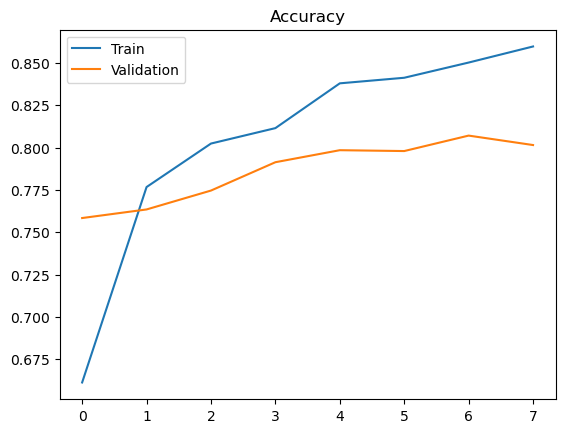

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Accuracy")
plt.show()

In [15]:
model.save("food11_model.keras")

In [16]:
calorie_dict = {
    "bread": 265,
    "dairy_product": 150,
    "dessert": 350,
    "egg": 155,
    "fried_food": 400,
    "meat": 250,
    "noodles_pasta": 300,
    "rice": 200,
    "seafood": 220,
    "soup": 120,
    "vegetable_fruit": 90
}

In [17]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Reverse class index mapping
class_indices = train_data.class_indices
labels = dict((v, k) for k, v in class_indices.items())

def predict_food_and_calories(img_path):

    img = image.load_img(img_path, target_size=(160, 160))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    confidence = np.max(prediction) * 100
    class_index = np.argmax(prediction)
    predicted_class = labels[class_index]

    predicted_class_clean = predicted_class.lower().replace(" ", "_")

    calories = calorie_dict.get(predicted_class_clean, "Not Available")

    return predicted_class, confidence, calories

    # Print results
    print("🔍 Food Detected:", predicted_class)
    print("📊 Confidence: {:.2f}%".format(confidence))
    print("🔥 Estimated Calories (per serving):", calories, "kcal")

In [28]:
food, conf, cal = predict_food_and_calories("testimage2.jpg")

print("Food:", food)
print("Confidence:", conf)
print("Calories:", cal)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Food: Egg
Confidence: 99.3932
Calories: 155


In [22]:
print(train_data.class_indices)


{'Bread': 0, 'Dairy product': 1, 'Dessert': 2, 'Egg': 3, 'Fried food': 4, 'Meat': 5, 'Noodles-Pasta': 6, 'Rice': 7, 'Seafood': 8, 'Soup': 9, 'Vegetable-Fruit': 10}
